# Choosing color palettes

📄 Source: https://seaborn.pydata.org/tutorial/color_palettes.html

Colours should fit **your data** and **your goal**. This page covers the general principles, then seaborn's tools to find a good palette quickly.

> Palette cells below show colour swatches (an HTML output). Colormaps (`as_cmap=True`) show as a colour bar.

In [1]:
import numpy as np
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white", rc={"xtick.major.pad": 1, "ytick.major.pad": 1})
np.random.seed(sum(map(ord, "palettes")))
print("seaborn", sns.__version__)

seaborn 0.13.2


## General principles for using color in plots

### Components of color

Computers specify colours as **RGB**, but for *perception* it's better to think in **hue**, **saturation** and **luminance**.

**Hue** = what makes "different colours" (red, blue...):

In [2]:
sns.husl_palette(8, s=.7)   # 8 hues, same saturation and lightness

[(0.9050206690302031, 0.485333660078793, 0.5536060216272151),
 (0.7746134071777862, 0.5735064999982632, 0.33461170957219066),
 (0.5960157928303208, 0.6360472513664188, 0.332709174532649),
 (0.33807407728540445, 0.6795473933377336, 0.4531666972263207),
 (0.3534153088659702, 0.6633810279867839, 0.6364737558329581),
 (0.36855688121452856, 0.6460104224517847, 0.7735274903942881),
 (0.6343430589262583, 0.5670865384343673, 0.8832295477118143),
 (0.8878791356686371, 0.4548300970941765, 0.8124926618667797)]

**Saturation** (chroma) = colourfulness. Different hues look more distinct when more saturated:

In [3]:
c = sns.color_palette("muted")[0]                  # one blue
sns.blend_palette([sns.desaturate(c, 0), c], 8)    # grey -> fully saturated blue

[(np.float64(0.5490196078431373),
  np.float64(0.5490196078431373),
  np.float64(0.5490196078431373)),
 (np.float64(0.5113725490196079),
  np.float64(0.5379469434832757),
  np.float64(0.5866666666666667)),
 (np.float64(0.47267973856209156),
  np.float64(0.526566705113418),
  np.float64(0.625359477124183)),
 (np.float64(0.43503267973856213),
  np.float64(0.5154940407535563),
  np.float64(0.6630065359477124)),
 (np.float64(0.3963398692810458),
  np.float64(0.5041138023836986),
  np.float64(0.7016993464052288)),
 (np.float64(0.35869281045751633),
  np.float64(0.493041138023837),
  np.float64(0.7393464052287582)),
 (np.float64(0.32),
  np.float64(0.48166089965397924),
  np.float64(0.7780392156862745)),
 (np.float64(0.2823529411764706),
  np.float64(0.47058823529411764),
  np.float64(0.8156862745098039))]

**Lightness** = how much light is emitted/reflected, from black to white:

In [4]:
sns.blend_palette([".1", c, ".95"], 8)   # near-black -> blue -> near-white

[(np.float64(0.1), np.float64(0.1), np.float64(0.1)),
 (np.float64(0.1514878892733564),
  np.float64(0.20463667820069203),
  np.float64(0.302076124567474)),
 (np.float64(0.20440599769319492),
  np.float64(0.3121799307958477),
  np.float64(0.5097654748173779)),
 (np.float64(0.25589388696655135),
  np.float64(0.41681660899653983),
  np.float64(0.7118415993848519)),
 (np.float64(0.37922722029988465),
  np.float64(0.5401499423298731),
  np.float64(0.8351749327181853)),
 (np.float64(0.5677393310265282),
  np.float64(0.675513264129181),
  np.float64(0.8730988081507113)),
 (np.float64(0.7614878892733563),
  np.float64(0.814636678200692),
  np.float64(0.912076124567474)),
 (np.float64(0.95), np.float64(0.95), np.float64(0.95))]

### Vary hue to distinguish categories

In which plot is it easier to count the triangles?

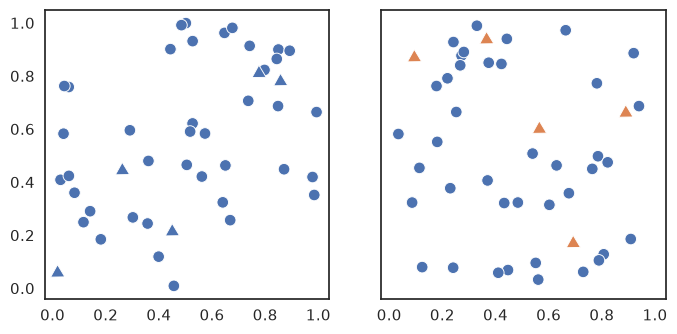

In [5]:
n = 45
rng = np.random.default_rng(200)
x = rng.uniform(0, 1, n * 2)
y = rng.uniform(0, 1, n * 2)
a = np.concatenate([np.zeros(n * 2 - 10), np.ones(10)])   # 0 = circle, 1 = triangle

f, axs = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True, sharex=True)
# Left: triangles differ only by shape and size
sns.scatterplot(
    x=x[::2], y=y[::2], style=a[::2], size=a[::2], legend=False,
    markers=["o", (3, 1, 1)], sizes=[70, 140], ax=axs[0],
)
# Right: triangles also differ by hue
sns.scatterplot(
    x=x[1::2], y=y[1::2], style=a[1::2], size=a[1::2], hue=a[1::2], legend=False,
    markers=["o", (3, 1, 1)], sizes=[70, 140], ax=axs[1],
)
f.tight_layout(w_pad=2)

On the right the orange triangles **pop out**: our visual system prioritises colour differences.

Hue is good for **categories**: most people can tell a moderate number of hues apart, colours with similar brightness look equally important, and they're easy to talk about ("the orange points"):

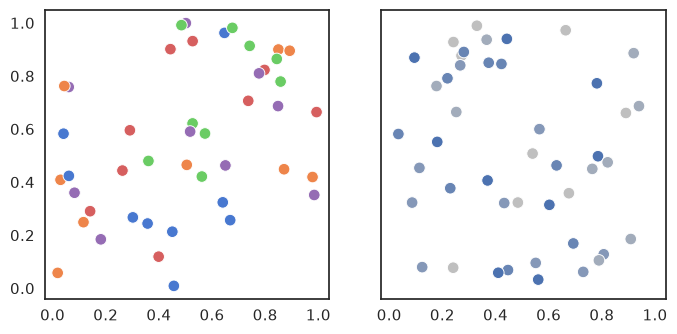

In [6]:
b = np.tile(np.arange(10), n // 5)   # 10 categories
f, axs = plt.subplots(1, 2, figsize=(7, 3.5), sharey=True, sharex=True)
sns.scatterplot(
    x=x[::2], y=y[::2], hue=b[::2],
    legend=False, palette="muted", s=70, ax=axs[0],         # categories by HUE
)
sns.scatterplot(
    x=x[1::2], y=y[1::2], hue=b[1::2],
    legend=False, palette="blend:.75,C0", s=70, ax=axs[1],  # categories by LUMINANCE of one blue
)
f.tight_layout(w_pad=2)

Left: easy to see 5 categories and describe "the blue points". Right: how many categories? How do you name one? And the grey dots fade, **de-emphasising** them, which is wrong if all categories are equally important.

Cautions: more than a handful of colours is hard to remember (readers keep checking the legend), and not everyone sees colour the same way. **Vary shape too** for colour-blind readers and black-and-white printing.

### Vary luminance to represent numbers

Hue is **not** good for numbers. Same bivariate histogram, left with a circular hue map, right with a luminance-based map:

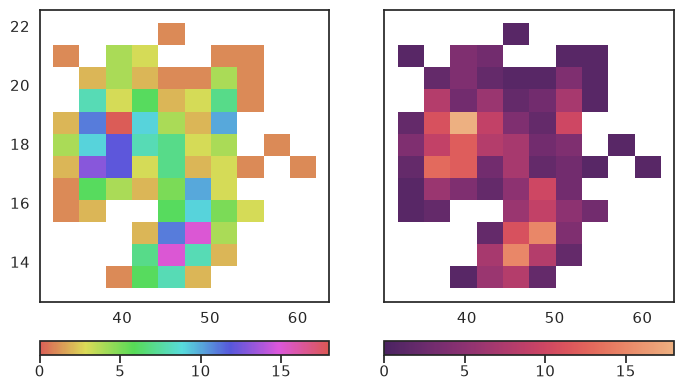

In [7]:
penguins = sns.load_dataset("penguins")
f, axs = plt.subplots(1, 2, figsize=(7, 4.25), sharey=True, sharex=True)
sns.histplot(
    data=penguins, x="bill_length_mm", y="bill_depth_mm",
    binwidth=(3, .75), cmap="hls", ax=axs[0],                 # hue changes with count: hard to read
    cbar=True, cbar_kws=dict(orientation="horizontal", pad=.1),
)
axs[0].set(xlabel="", ylabel="")
sns.histplot(
    data=penguins, x="bill_length_mm", y="bill_depth_mm",
    binwidth=(3, .75), cmap="flare_r", ax=axs[1],             # brightness changes with count: two peaks are clear
    cbar=True, cbar_kws=dict(orientation="horizontal", pad=.1),
)
axs[1].set(xlabel="", ylabel="")
f.tight_layout(w_pad=3)

The luminance palette reveals **two peaks**; the hue one hides them. Luminance changes read as changes in **importance**. A little hue variation on top (not pure grey) makes small differences easier to see.

Palette choice is not just aesthetics: it can **reveal or hide** patterns. And aesthetics still matter: people learn more from figures they want to look at.

## Tools for choosing color palettes

The main function is **`color_palette()`**. Every function with a `palette=` argument uses it internally.
- Argument: a palette name, or a family name + parameters (delegated to e.g. `cubehelix_palette`), or a list of any matplotlib colours.
- Returns a list of RGB tuples (with hex conversion and a swatch display).
- No argument → the current default palette. Change the default with `set_palette()` (same arguments).

Three classes of palettes:
- **qualitative**: categorical data
- **sequential**: numeric data
- **diverging**: numeric data with a meaningful midpoint

## Qualitative color palettes

Most of the variation is in **hue**. The default seaborn palette has 10 hues:

In [8]:
sns.color_palette()

[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

In [9]:
# Same order as matplotlib's "tab10", but less intense
sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

Seaborn has **six** versions of matplotlib's palette, differing in luminance and saturation: `deep`, `muted`, `pastel`, `bright`, `dark`, `colorblind`.

In [10]:
for name in ["deep", "muted", "pastel", "bright", "dark", "colorblind"]:
    print(name, sns.color_palette(name).as_hex()[:5])   # first 5 colours as hex codes

sns.color_palette("colorblind")

deep ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3']
muted ['#4878d0', '#ee854a', '#6acc64', '#d65f5f', '#956cb4']
pastel ['#a1c9f4', '#ffb482', '#8de5a1', '#ff9f9b', '#d0bbff']
bright ['#023eff', '#ff7c00', '#1ac938', '#e8000b', '#8b2be2']
dark ['#001c7f', '#b1400d', '#12711c', '#8c0800', '#591e71']
colorblind ['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc']


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

`deep` (the default) is pleasant but less distinct; for publication graphics consider how palettes look to colour-blind readers (`colorblind` is designed for that).

### Using circular color systems

For an **arbitrary number** of categories, take evenly spaced hues around a colour wheel (constant brightness and saturation). Seaborn does this automatically when it needs more colours than the default cycle has. The simple version uses `hls`:

In [11]:
sns.color_palette("hls", 8)

[(0.86, 0.3712, 0.33999999999999997),
 (0.86, 0.7612000000000001, 0.33999999999999997),
 (0.5688000000000001, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.5012000000000001),
 (0.33999999999999997, 0.8287999999999999, 0.86),
 (0.33999999999999997, 0.43879999999999986, 0.86),
 (0.6311999999999998, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.6987999999999996)]

Equal RGB lightness doesn't *look* equally intense (yellow/green look brighter). The **husl** (HSLuv) system evens this out:

In [12]:
sns.color_palette("husl", 8)

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.8087954113106306, 0.5634700050056693, 0.19502642696727285),
 (0.5920891529639701, 0.6418467016378244, 0.1935069134991043),
 (0.19783576093349015, 0.6955516966063037, 0.3995301037444499),
 (0.21044753832183283, 0.6773105080456748, 0.6433941168468681),
 (0.22335772267769388, 0.6565792317435265, 0.8171355503265633),
 (0.6423044349219739, 0.5497680051256467, 0.9582651433656727),
 (0.9603888539940703, 0.3814317878772117, 0.8683117650835491)]

### Using categorical Color Brewer palettes

Color Brewer also has good qualitative palettes:

In [13]:
sns.color_palette("Set2")

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

In [14]:
# Brewer qualitative palettes have different lengths; you get the full list by default
sns.color_palette("Paired")

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

## Sequential color palettes

For data going from low/uninteresting to high/interesting values. The main variation is **luminance**. Seaborn defaults to a sequential palette for numeric mappings (still set with `hue=` for historical reasons).

### Perceptually uniform palettes

The best sequential palettes are **perceptually uniform**: how different two colours look is proportional to the difference in data values. Seaborn has four: `rocket`, `mako`, `flare`, `crest`.
`rocket` and `mako` have a very wide luminance range, good for **heatmaps** (colour fills the space):

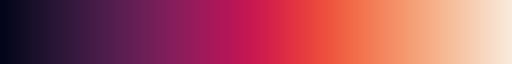

In [15]:
sns.color_palette("rocket", as_cmap=True)

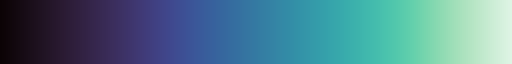

In [16]:
sns.color_palette("mako", as_cmap=True)

Their extremes are near white, so they're bad for **lines and points** on a white/grey background. Use `flare` and `crest` there: narrower luminance range, a bit more hue variation, and light = small values:

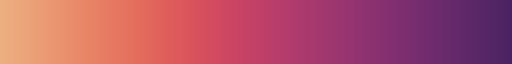

In [17]:
sns.color_palette("flare", as_cmap=True)

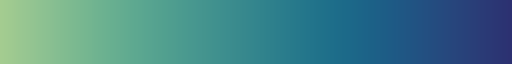

In [18]:
sns.color_palette("crest", as_cmap=True)

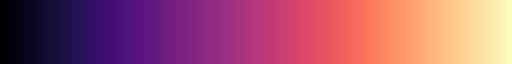

In [19]:
# matplotlib's perceptually uniform maps work too
sns.color_palette("magma", as_cmap=True)

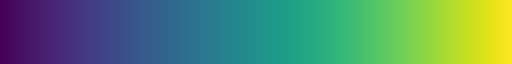

In [20]:
sns.color_palette("viridis", as_cmap=True)

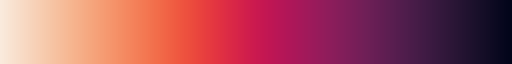

In [21]:
# Every continuous colormap has a reversed version: add "_r"
sns.color_palette("rocket_r", as_cmap=True)

### Discrete vs. continuous mapping

When seaborn makes **discrete** colours from a sequential map, it **skips the extreme values**. Compare with the continuous `rocket` above:

In [22]:
sns.color_palette("rocket")

[(0.20973515, 0.09747934, 0.24238489),
 (0.43860848, 0.12177004, 0.34119475),
 (0.67824099, 0.09192342, 0.3504148),
 (0.8833417, 0.19830556, 0.26014181),
 (0.95381595, 0.46373781, 0.31769923),
 (0.96516917, 0.70776351, 0.5606593)]

Seaborn uses the discrete version for categorical data and the continuous one for numeric mapping. Discrete sequential palettes suit **ordered categories** (e.g. small/medium/large).

### Sequential "cubehelix" palettes

Cubehelix: RGB-based, linear change in brightness with some hue rotation. Not perfectly uniform, but many good properties and **fully parameterisable**.

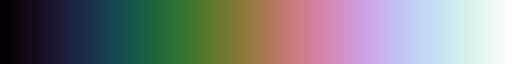

In [23]:
sns.color_palette("cubehelix", as_cmap=True)   # matplotlib's default cubehelix

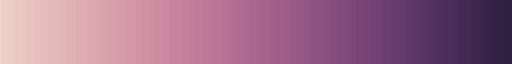

In [24]:
# seaborn's version: less hue rotation, narrower intensity range, reversed (light = low)
sns.cubehelix_palette(as_cmap=True)

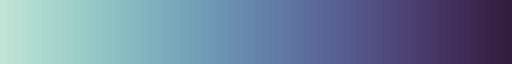

In [25]:
# start (0-3) = starting hue, rot = number of rotations (usually -1 to 1)
sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)

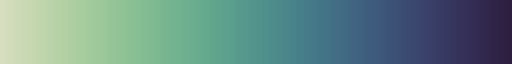

In [26]:
# More rotation -> more hue variation
sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)

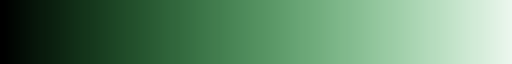

In [27]:
# Control the endpoints' darkness/lightness and the direction
sns.cubehelix_palette(start=2, rot=0, dark=0, light=.95, reverse=True, as_cmap=True)

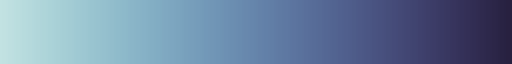

In [28]:
# String shortcut "ch:" with parameter names...
sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True)

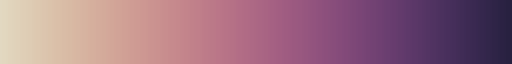

In [29]:
# ...or just their first letters
sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)

### Custom sequential palettes

`light_palette` / `dark_palette`: seed with **one colour** and ramp from light (or dark) to it:

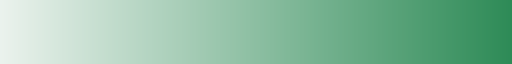

In [30]:
sns.light_palette("seagreen", as_cmap=True)

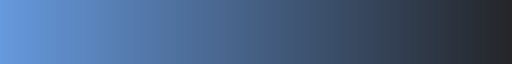

In [31]:
sns.dark_palette("#69d", reverse=True, as_cmap=True)

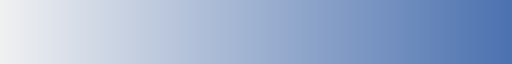

In [32]:
# Same thing as a string, usable anywhere palette= is accepted
sns.color_palette("light:b", as_cmap=True)

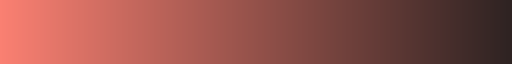

In [33]:
# Reverse with "_r"
sns.color_palette("dark:salmon_r", as_cmap=True)

### Sequential Color Brewer palettes

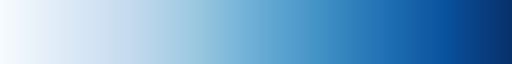

In [34]:
sns.color_palette("Blues", as_cmap=True)   # one hue

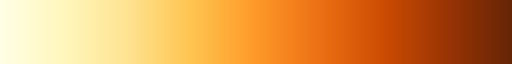

In [35]:
sns.color_palette("YlOrBr", as_cmap=True)  # multi-hue

## Diverging color palettes

For data where **both low and high values are interesting** around a midpoint (often 0) that should be **de-emphasised**. Two dominant hues, one at each pole, with similar brightness and saturation at both ends. **Use this for a correlation heatmap.**

### Perceptually uniform diverging palettes

`vlag` and `icefire`, blue ("cold") to red ("hot"):

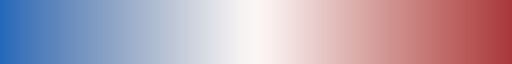

In [36]:
sns.color_palette("vlag", as_cmap=True)

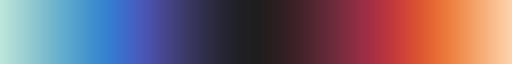

In [37]:
sns.color_palette("icefire", as_cmap=True)

### Custom diverging palettes

`diverging_palette(h_neg, h_pos, ...)`: two hues in degrees (husl system), optionally saturation `s` and lightness `l`:

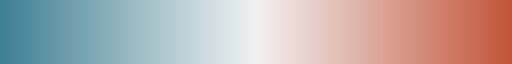

In [38]:
sns.diverging_palette(220, 20, as_cmap=True)

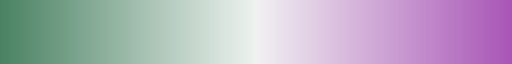

In [39]:
sns.diverging_palette(145, 300, s=60, as_cmap=True)   # away from the usual cold-hot

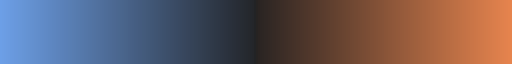

In [40]:
sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True)   # dark midpoint

⚠️ Red-green is intuitive but **should be avoided** (red-green colour blindness).

### Other diverging palettes

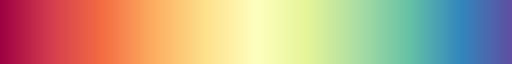

In [41]:
sns.color_palette("Spectral", as_cmap=True)

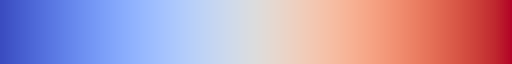

In [42]:
# coolwarm: less contrast between the middle and the extremes
sns.color_palette("coolwarm", as_cmap=True)

More reading: NASA Earth Observatory's *Subtleties of Color* blog series, and matplotlib's *Choosing Colormaps* (matplotlib notebook 07).

## Try it (from the README): `sns.color_palette("colorblind")`

Text(0.5, 1.0, 'palette="colorblind" + style for colour-blind readers')

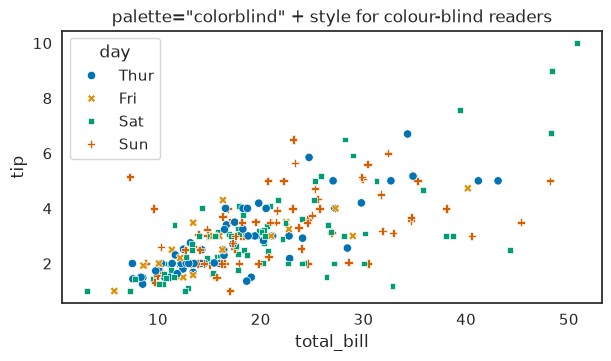

In [43]:
tips = sns.load_dataset("tips")
fig, ax = plt.subplots(figsize=(6, 3.5), layout="constrained")
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day", style="day",   # hue AND style for accessibility
                palette="colorblind", ax=ax)
ax.set_title('palette="colorblind" + style for colour-blind readers')

## Key takeaways

| Data | Palette type | Seaborn picks |
| :-- | :-- | :-- |
| categories | qualitative (vary **hue**) | `deep` (default), `colorblind`, `Set2`, `husl` for many |
| ordered numbers | sequential (vary **luminance**) | `rocket`/`mako` (heatmaps), `flare`/`crest` (lines, points), `viridis`, `ch:...` |
| numbers around a midpoint | diverging | `vlag`, `icefire`, `diverging_palette(...)`, `coolwarm` |

- `sns.color_palette(name, n, as_cmap=...)` everywhere; `sns.set_palette(...)` for the default.
- Avoid rainbow (`hls`) for numbers and red-green for anything important.